In [1]:
# 1 思想 分类器 
# 2 如何？ 寻求一个最优的超平面 分类
# 3 核：line
# 4 数据：样本 
# 5 训练  SVM_create  train predict
# svm本质 寻求一个最优的超平面 分类
# svm 核: line
# 身高体重 训练 预测 
import cv2
import numpy as np
import matplotlib.pyplot as plt
#1 准备data
rand1 = np.array([[155,48],[159,50],[164,53],[168,56],[172,60]])
rand2 = np.array([[152,53],[156,55],[160,56],[172,64],[176,65]])

# 2 label
label = np.array([[0],[0],[0],[0],[0],[1],[1],[1],[1],[1]])

# 3 data
data = np.vstack((rand1,rand2))
data = np.array(data,dtype='float32')

# svm 所有的数据都要有label
# [155,48] -- 0 女生 [152,53] ---1  男生
# 监督学习 0 负样本 1 正样本

# 4 训练
svm = cv2.ml.SVM_create() # ml  机器学习模块 SVM_create() 创建
# 属性设置
svm.setType(cv2.ml.SVM_C_SVC) # svm type
svm.setKernel(cv2.ml.SVM_LINEAR) # line
svm.setC(0.01)
# 训练
result = svm.train(data,cv2.ml.ROW_SAMPLE,label)
# 预测
pt_data = np.vstack([[167,55],[162,57]]) #0 女生 1男生
pt_data = np.array(pt_data,dtype='float32')
print(pt_data)
(par1,par2) = svm.predict(pt_data)
print(par2)

[[167.  55.]
 [162.  57.]]
[[0.]
 [1.]]


支持向量数量: 1
支持向量:
[[ 0.07677064 -0.2065688 ]]


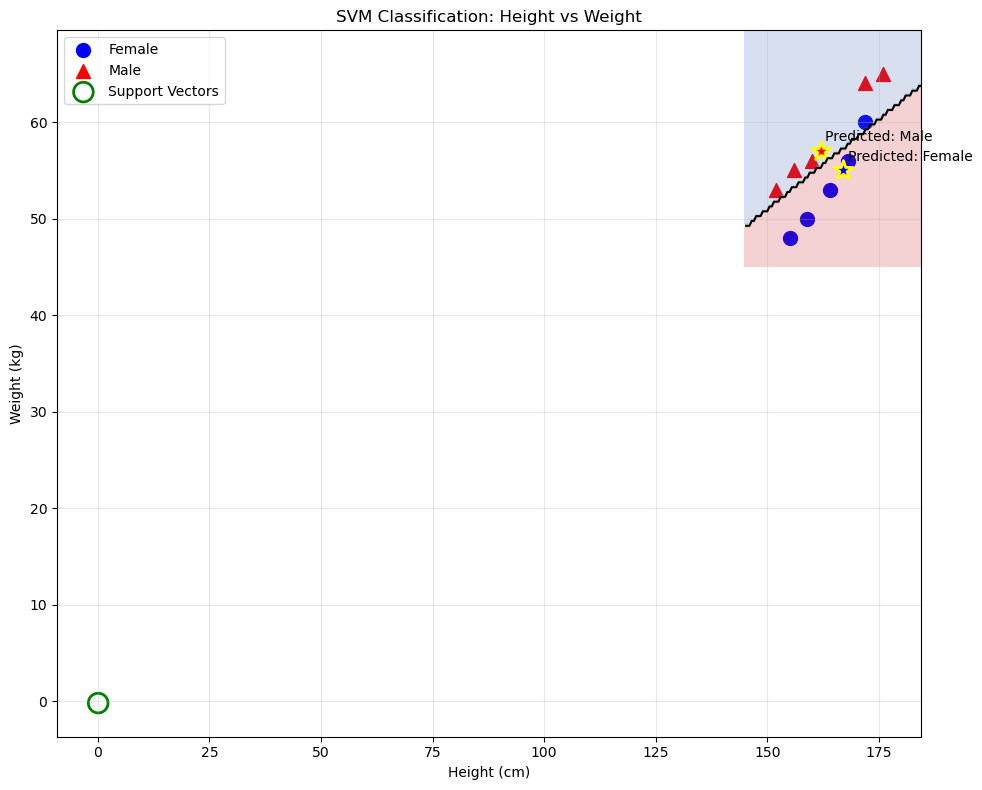

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_svm():
    """可视化 SVM 分类结果"""
    # 1. 准备数据
    rand1 = np.array([[155,48],[159,50],[164,53],[168,56],[172,60]])
    rand2 = np.array([[152,53],[156,55],[160,56],[172,64],[176,65]])

    data = np.vstack((rand1, rand2)).astype(np.float32)
    labels = np.array([[0],[0],[0],[0],[0],[1],[1],[1],[1],[1]])

    # 2. 训练 SVM
    svm = cv2.ml.SVM_create()
    svm.setType(cv2.ml.SVM_C_SVC)
    svm.setKernel(cv2.ml.SVM_LINEAR)
    svm.setC(0.01)
    svm.train(data, cv2.ml.ROW_SAMPLE, labels)

    # 3. 获取支持向量
    support_vectors = svm.getSupportVectors()
    print(f"支持向量数量: {len(support_vectors)}")
    print("支持向量:")
    print(support_vectors)

    # 4. 可视化
    plt.figure(figsize=(10, 8))

    # 绘制样本点
    plt.scatter(rand1[:, 0], rand1[:, 1], c='blue', s=100, marker='o', label='Female')
    plt.scatter(rand2[:, 0], rand2[:, 1], c='red', s=100, marker='^', label='Male')

    # 绘制支持向量
    if support_vectors is not None:
        plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
                   s=200, facecolors='none', edgecolors='green',
                   linewidths=2, label='Support Vectors')

    # 绘制决策边界
    x_min, x_max = 145, 185
    y_min, y_max = 45, 70

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                         np.arange(y_min, y_max, 0.5))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    _, Z = svm.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdYlBu)
    plt.contour(xx, yy, Z, colors='black', levels=[0.5])

    # 添加标签
    plt.xlabel('Height (cm)')
    plt.ylabel('Weight (kg)')
    plt.title('SVM Classification: Height vs Weight')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 添加预测点
    test_points = [[167, 55], [162, 57]]
    test_labels = ['Predicted: Female', 'Predicted: Male']

    for i, (pt, label) in enumerate(zip(test_points, test_labels)):
        pred = svm.predict(np.array([pt], dtype=np.float32))[1][0][0]
        color = 'blue' if pred == 0 else 'red'
        plt.scatter(pt[0], pt[1], c=color, s=200, marker='*',
                    edgecolors='yellow', linewidths=2)
        plt.annotate(label, (pt[0]+1, pt[1]+1), fontsize=10)

    plt.tight_layout()
    plt.show()

    return svm

# 运行
svm_model = visualize_svm()